In [54]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


In [55]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 01 - Prepareção dos Dados

Carrega o dataset Iris tranforma a coluna de especie em numero para categorização
e divide as amostras entre conjuntos de treino e de teste, reservando 20% dos dados para a avaliação final.

In [56]:
iris_df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv') 
iris_df['Species'] = iris_df['Species'].astype('category').cat.codes
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [57]:
X = iris_df.drop(["Id", "Species"], axis=1, errors='ignore')
y = iris_df["Species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2 SVM

O algoritmo procura a melhor fronteira matemática para separar as classes, sendo muito sensível à configuração da margem e do formato dessa fronteira.

* # 2.1 - Sem GridSearchCV.

O modelo é treinado rapidamente utilizando os valores originais da biblioteca (como kernel='rbf' e C=1.0). É útil para uma avaliação inicial, mas pode não oferecer o limite de decisão ideal em problemas mais complexos.

In [58]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)
y_pred_SVM = model.predict(X_test)

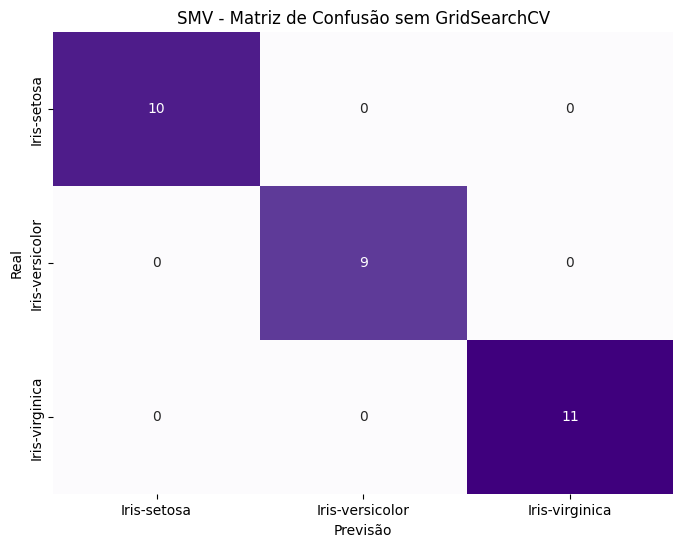

In [87]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_SVM)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('SMV - Matriz de Confusão sem GridSearchCV')
plt.show()

* # 2.2 - Com GridSearchCV.

Testa sistematicamente combinações de flexibilidade da margem (C) e transformações matemáticas (kernel) através de validação cruzada. O algoritmo apenas finaliza o treino após descobrir matematicamente qual é a configuração que minimiza a taxa de erro.

In [61]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)
y_pred_grid_svm = grid_search.predict(X_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


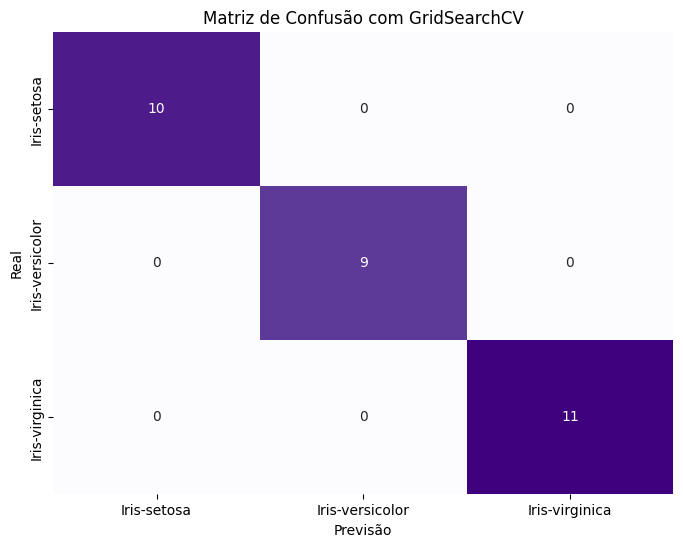

In [63]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_grid_svm)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('SMV - Matriz de Confusão com GridSearchCV')
plt.show()

# 3 - Arvore de Decisão

Este modelo cria uma estrutura de fluxograma com regras do tipo "If/Else" para classificar os dados com base nas medidas das flores.

# 3.1 - Sem GridSearchCV

O modelo ramifica o fluxograma sem limite de profundidade até que todas as amostras de treino estejam perfeitamente separadas, o que é até rapido, mas pode aumentar o risco de deixar o modelo viciado, prejudicando a performance em dados novos.

In [64]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

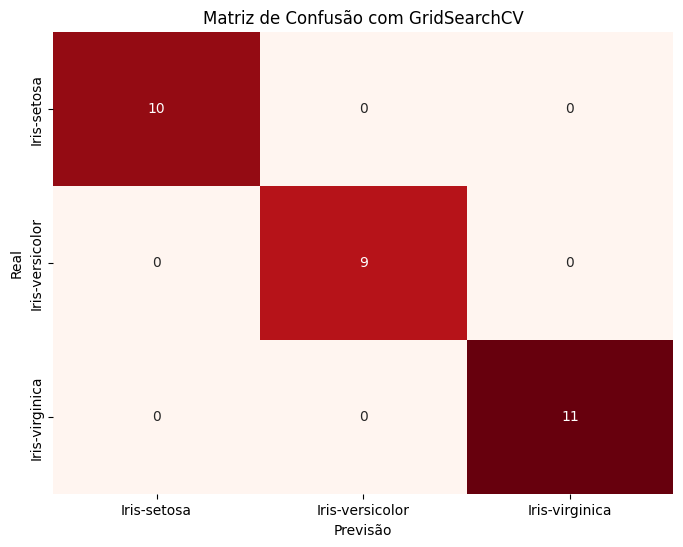

In [66]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tree)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Arvore de Decisão - Matriz de Confusão Sem GridSearchCV')
plt.show()

# 3.2 - Com GridSearchCV.

Ja com o GS ele tenta diferentes limites, testando a profundidade máxima da árvore (max_depth) e a quantidade mínima de amostras necessárias para criar uma nova regra (min_samples_split). Isto "poda a árvore", fazendo que as regras criadas servem para generalizar e criar mais variedades de resultados, e não apenas para memorizar um padrão e deixar o modelo Viciado.

In [86]:
parametros_tree = {'max_depth': [None, 3, 5, 7], 
 'min_samples_split': [2, 5, 10]}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), parametros_tree, cv=5)
grid_tree.fit(X_train, y_train)
y_pred_grid_tree = grid_tree.predict(X_test)

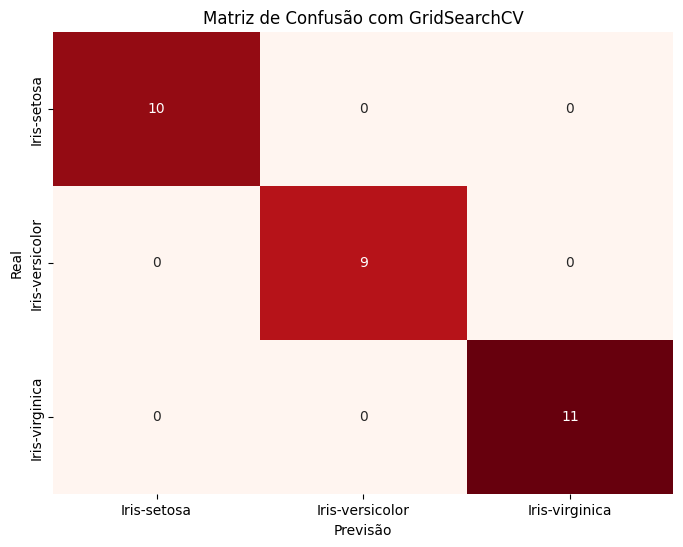

In [69]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_grid_tree)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Arvore de Decisão - Matriz de Confusão Com GridSearchCV')
plt.show()

# 4 - Floresta Aleatória

O algoritmo constrói um conjunto de Árvores de Decisão, em que a classificação final é decidida pela votação da maioria pela média.

# 4.1 - Sem GridSearchCV.

Inicializa a floresta com as definições normais (geralmente 100 árvores sem limite de profundidade). Por ser um modelo de conjunto (ensemble), a versão padrão sem precisar alterar nada já apresenta resultados bons logo na primeira tentativa.

In [70]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

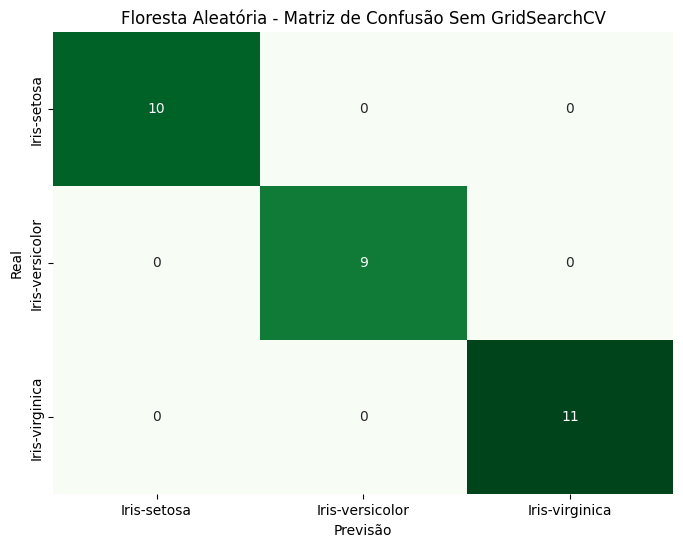

In [92]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Floresta Aleatória - Matriz de Confusão Sem GridSearchCV')
plt.show()

# 4.2 - Com GridSearchCV.

Refina o poder de processamento e a precisão da floresta, testando variações no número total de árvores construídas (n_estimators) e nas regras de profundidade de cada árvore individual. Isto permite encontrar o equilíbrio exato entre o tempo de processamento necessário e o ganho real de exatidão.

In [73]:
parametros_rf = {'n_estimators': [50, 100, 200], 
                 'max_depth': [None, 3, 5]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), parametros_rf, cv=5)
grid_rf.fit(X_train, y_train)
y_pred_grid_rf = grid_rf.predict(X_test)

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_grid_rf)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Floresta Aleatória - Matriz de Confusão com GridSearchCV')
plt.show()

# 5 - Boosting

Este modelo também constrói várias Árvores de Decisão,sequencialmente ou seja em vez de serem independentes, cada nova árvore é criada com o objetivo específico de corrigir os erros cometidos pelas árvores anteriores como se fosse uma especie de "corrente".

# 5.1 - Sem GridSearchCV.

O algoritmo é treinado com as configurações base. Ele já costuma apresentar um desempenho muito forte sem muita alteração no inicio, mas, por tentar corrigir todos os erros, pode acabar decorando o ruído dos dados de treino se não for controlado.

In [76]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

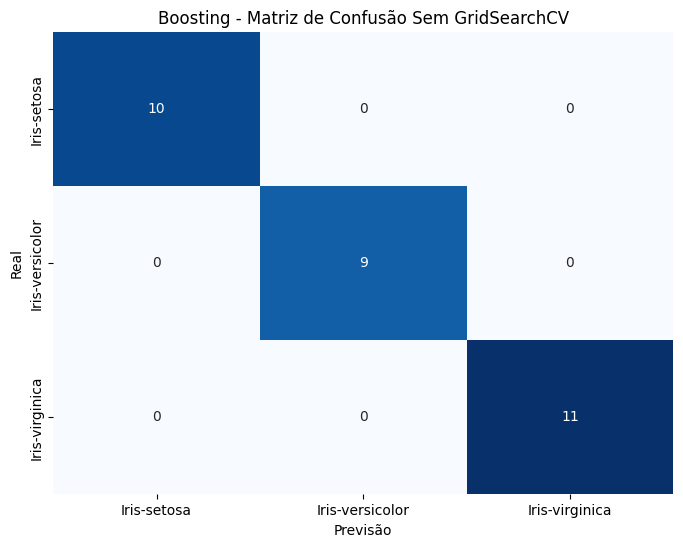

In [88]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_gb)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Boosting - Matriz de Confusão Sem GridSearchCV')
plt.show()

# 5.2 - Com GridSearchCV.

Aqui o tem equilíbrio delicado entre a quantidade de árvores e a velocidade com que o modelo aprende. Quanto testamos essas combinações pela validação cruzada, o GS garante que o modelo aprenda de forma gradual e robusta, parando antes de começar a memorizar os dados em excesso.

In [79]:
parametros_gb = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.2]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), parametros_gb, cv=5)
grid_gb.fit(X_train, y_train)
y_pred_grid_gb = grid_gb.predict(X_test)

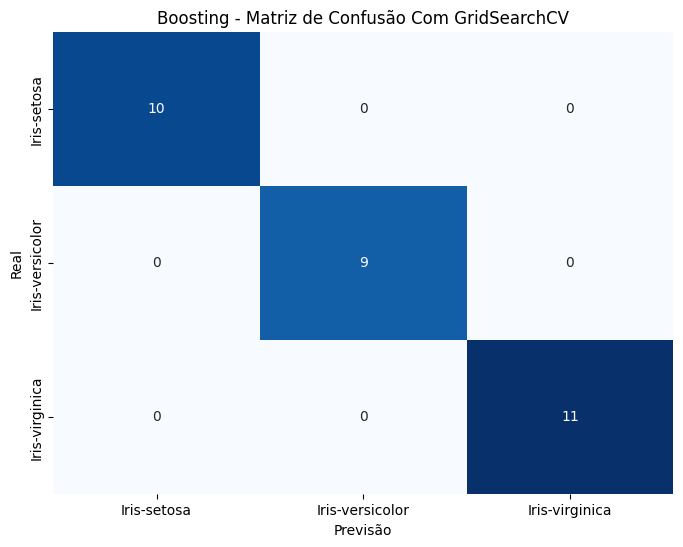

In [90]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_grid_gb)
nomes_especies = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=nomes_especies, yticklabels=nomes_especies)

plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Boosting - Matriz de Confusão Com GridSearchCV')
plt.show()

# 6 - Comparação

In [82]:
dados = {
    'Modelo': [
        'SVM', 'Árvore de Decisão', 'Floresta Aleatória', 'Gradient Boosting',
        'SVM', 'Árvore de Decisão', 'Floresta Aleatória', 'Gradient Boosting'
    ],
    'Acurácia': [
        1.0000, 0.9333, 0.9000, 0.9667, 
        0.9667, 0.9333, 0.9667, 0.9667
    ],
    'Sensibilidade': [
        1.0000, 0.9333, 0.9000, 0.9667, 
        0.9667, 0.9333, 0.9667, 0.9667
    ],
    'Otimização': [
        'Sem GridSearchCV', 'Sem GridSearchCV', 'Sem GridSearchCV', 'Sem GridSearchCV',
        'Com GridSearchCV', 'Com GridSearchCV', 'Com GridSearchCV', 'Com GridSearchCV'
    ]
}


In [83]:
comparacao = pd.DataFrame(dados)
comparacao['Acurácia'] = (
    comparacao['Acurácia'] * 100
).round(2)

comparacao['Sensibilidade'] = (
    comparacao['Sensibilidade'] * 100
).round(2)
comparacao

,Modelo,Acurácia,Sensibilidade,Otimização
0,SVM,100.00,100.00,Sem GridSearchCV
1,Árvore de Decisão,93.33,93.33,Sem GridSearchCV
2,Floresta Aleatória,90.00,90.00,Sem GridSearchCV
3,Gradient Boosting,96.67,96.67,Sem GridSearchCV
4,SVM,96.67,96.67,Com GridSearchCV
5,Árvore de Decisão,93.33,93.33,Com GridSearchCV
6,Floresta Aleatória,96.67,96.67,Com GridSearchCV
7,Gradient Boosting,96.67,96.67,Com GridSearchCV


# 7 - Conclusão

O modelo que teve o melhor desempenho sem o uso do GridSearchCV foi o Support Vector Machine (SVM), ele alcançou a pontuação máxima de 100.00% tanto em precisão quanto em sensibilidade.

Analisando como os resultados mudaram depois de aplicarmos o GridSearchCV se seguiu assim:

* Floresta Aleatória: Este foi o algoritmo que mais ganhou com o ajuste do GridSearchCV, saindo de um desempenho fraco na configuração inicial (90.00%) para 96.67%.
  
* Gradient Boosting e Árvore de Decisão: Ambos não mostraram nenhuma variação, mesmo após o ajuste. Suas pontuações permaneceram fixas em 96.67% e 93.33%, respectivamente.
  
* SVM: Surpreendendo, a aplicação do GridSearchCV deixando as regras mais estritas através do ajuste fez com que o desempenho dele caísse bastante indo do seu 100.00% anterior sem o GridSearchCV para 96.67%.

Embora o SVM, na sua configuração inicial, seja o campeão em termos de números nesta tabela, os resultados após o ajuste sugerem que Floresta Aleatória, Gradient Boosting e o SVM (agora com pontuações iguais de 96.67%) compõem o grupo de algoritmos mais confiáveis e consistentes deste teste.